In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
def safe_read_csv(path, columns):
    """read CSV: if file not found or empty, return DataFrame"""
    if not os.path.exists(path):
        return pd.DataFrame(columns=columns)

    try:
        df = pd.read_csv(path, header=0)
        if df.empty:
            return pd.DataFrame(columns=columns)

        df.columns = columns
        return df

    except Exception as e:
        return pd.DataFrame(columns=columns)    

In [4]:
session_dir = "/home/majue/sip_case_study/Pseudo-PFLOW/nishioshi_case/"
origin_path = os.path.join(session_dir,f"trip_23213.csv")

base_columns = ['person_id','departure_time','origin_lon','origin_lat','destination_lon','destination_lat','transport','purpose','labor']
origin_data = safe_read_csv(origin_path, base_columns)

print(len(origin_data))
print(origin_data.transport.value_counts())
print(origin_data.transport.value_counts(normalize=True) * 100)

534170
transport
1    156417
3    151539
5     70934
2     60531
0     55165
4     39584
Name: count, dtype: int64
transport
1    29.282251
3    28.369059
5    13.279293
2    11.331786
0    10.327237
4     7.410375
Name: proportion, dtype: float64


In [4]:
session_dir = "/home/majue/sip_case_study/Pseudo-PFLOW/nishioshi_case/"
labor_path = os.path.join(session_dir, f'person/trip/',f"23/",f"trip_23213_labor.csv")
nolabor_path = os.path.join(session_dir, f'person/trip',f"23/",f"trip_23213_nolabor.csv")
student_path = os.path.join(session_dir, f'person/trip',f"23/",f"trip_23213_student.csv")

base_columns = ['person_id','departure_time','origin_lon','origin_lat','destination_lon','destination_lat','transport','purpose','labor']
labor_data = safe_read_csv(labor_path, base_columns)
nolabor_data = safe_read_csv(nolabor_path, base_columns)
student_data = safe_read_csv(student_path, base_columns)

combined_data = pd.concat([labor_data, nolabor_data, student_data], ignore_index=True, axis=0)

print(len(labor_data))
print(len(nolabor_data))
print(len(student_data))
print(len(combined_data))

print(combined_data.transport.value_counts())
print(combined_data.transport.value_counts(normalize=True) * 100)

4042
2521
1980
8543
transport
3    4651
2     992
0     960
1     810
5     684
4     446
Name: count, dtype: int64
transport
3    54.442233
2    11.611846
0    11.237270
1     9.481447
5     8.006555
4     5.220648
Name: proportion, dtype: float64


In [4]:
session_dir = "/home/majue/sip_case_study/Pseudo-PFLOW/nishioshi_case/"
labor_path = os.path.join(session_dir, f'person/trajectory/',f"23/",f"trajectory_23213_labor.csv")
nolabor_path = os.path.join(session_dir, f'person/trajectory/',f"23/",f"trajectory_23213_nolabor.csv")
student_path = os.path.join(session_dir, f'person/trajectory/',f"23/",f"trajectory_23213_student.csv")

columns = ['person_id','departure_time','timestamp','lon','lat','transport','purpose','labor','link_id']
labor_data = pd.read_csv(labor_path, header=0)
labor_data.columns = columns
nolabor_data = pd.read_csv(nolabor_path, header=0)
nolabor_data.columns = columns
student_data = pd.read_csv(student_path, header=0)
labor_data.columns = columns

combined_data = pd.concat([labor_data, nolabor_data, student_data], ignore_index=True, axis=0)

In [5]:
len(combined_data)

649034

In [6]:
labor_data.head()

,person_id,departure_time,timestamp,lon,lat,transport,purpose,labor,link_id
0,74822164,1443654913114,2015-10-01 08:15:13,137.048180,34.860979,2,2,WORKER,9206203.0
1,74822164,1443654932215,2015-10-01 08:15:32,137.048067,34.861604,2,2,WORKER,9195672.0
2,74822164,1443654962191,2015-10-01 08:16:02,137.049017,34.862212,2,2,WORKER,9191392.0
3,74822164,1443654987100,2015-10-01 08:16:27,137.049605,34.862879,2,2,WORKER,9191380.0
4,74822164,1443655013191,2015-10-01 08:16:53,137.050217,34.863578,2,2,WORKER,9191382.0


# Test result 1

In [15]:
session_dir = "/home/majue/sip_case_study/Pseudo-PFLOW/nishioshi_case/"
labor_path = os.path.join(session_dir, f'person/trip_taxi/',f"23/1/",f"trip_23213_labor.csv")
nolabor_path = os.path.join(session_dir, f'person/trip_taxi',f"23/1/",f"trip_23213_nolabor.csv")
student_path = os.path.join(session_dir, f'person/trip_taxi',f"23/1/",f"trip_23213_student.csv")

base_columns = ['person_id','departure_time','origin_lon','origin_lat','destination_lon','destination_lat','transport','purpose','labor']
labor_data = safe_read_csv(labor_path, base_columns)
nolabor_data = safe_read_csv(nolabor_path, base_columns)
student_data = safe_read_csv(student_path, base_columns)

combined_data = pd.concat([labor_data, nolabor_data, student_data], ignore_index=True, axis=0)

print(len(labor_data))
print(len(nolabor_data))
print(len(student_data))
print(len(combined_data))

print(combined_data.transport.value_counts())
print(combined_data.transport.value_counts(normalize=True) * 100)


3557
2321
1513
7391
transport
3    4432
0    1916
2     853
1     189
5       1
Name: count, dtype: int64
transport
3    59.964822
0    25.923420
2    11.541063
1     2.557164
5     0.013530
Name: proportion, dtype: float64


# Test result 2 (waiting time = 5min)

In [12]:
session_dir = "/home/majue/sip_case_study/Pseudo-PFLOW/nishioshi_case/"
labor_path = os.path.join(session_dir, f'person/trip_taxi/',f"23/2/",f"trip_23213_labor.csv")
nolabor_path = os.path.join(session_dir, f'person/trip_taxi',f"23/2/",f"trip_23213_nolabor.csv")
student_path = os.path.join(session_dir, f'person/trip_taxi',f"23/2/",f"trip_23213_student.csv")

base_columns = ['person_id','departure_time','origin_lon','origin_lat','destination_lon','destination_lat','transport','purpose','labor']
labor_data = safe_read_csv(labor_path, base_columns)
nolabor_data = safe_read_csv(nolabor_path, base_columns)
student_data = safe_read_csv(student_path, base_columns)

combined_data = pd.concat([labor_data, nolabor_data, student_data], ignore_index=True, axis=0)

print(len(labor_data))
print(len(nolabor_data))
print(len(student_data))
print(len(combined_data))

print(combined_data.transport.value_counts())
print(combined_data.transport.value_counts(normalize=True) * 100)

3583
2351
1568
7502
transport
3    4349
0     960
2     941
8     883
1     279
5      72
4      18
Name: count, dtype: int64
transport
3    57.971208
0    12.796588
2    12.543322
8    11.770195
1     3.719008
5     0.959744
4     0.239936
Name: proportion, dtype: float64


In [13]:
def haversine(lon1, lat1, lon2, lat2):
    R = 6371000  # Earth radius in meters
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c  # meters

combined_data["od_distance_m"] = haversine(
    combined_data.origin_lon,
    combined_data.origin_lat,
    combined_data.destination_lon,
    combined_data.destination_lat
)
combined_data["od_distance_km"] = combined_data["od_distance_m"] / 1000

combined_data.groupby("transport")["od_distance_km"].describe()

,count,mean,std,min,25%,50%,75%,max
transport,,,,,,,,
0,960.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,279.0,0.364997,0.213202,0.005834,0.190716,0.317965,0.536475,0.935661
2,941.0,0.979868,0.766449,0.005834,0.468057,0.775096,1.244811,4.474549
3,4349.0,6.020780,5.954515,0.111523,1.774700,4.140291,8.166809,33.481307
4,18.0,3.206295,1.874320,1.471174,1.932998,2.242971,4.010527,8.559297
5,72.0,1.710254,1.423083,0.018850,0.759963,1.233190,2.135513,6.487518
8,883.0,17.021210,16.222684,0.367509,4.357270,9.300714,33.877942,91.343533


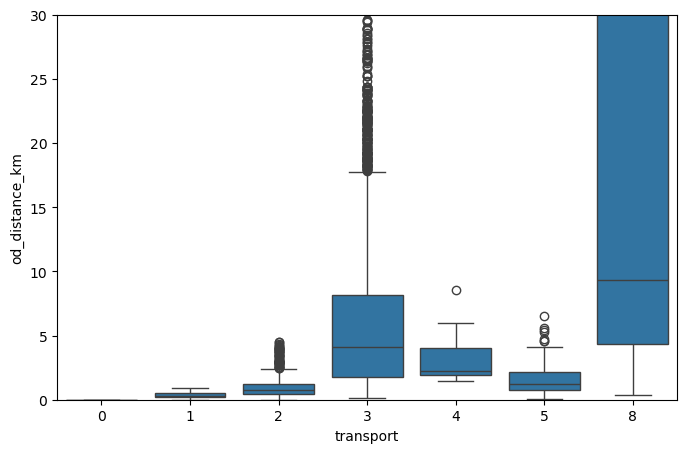

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=combined_data, x="transport", y="od_distance_km")
plt.ylim(0, 30)  # 避免极端值拉长
plt.show()

883


/tmp/ipykernel_1319906/2248104164.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  taxi_data["departure_hour"] = taxi_data["departure_time"] / 3600


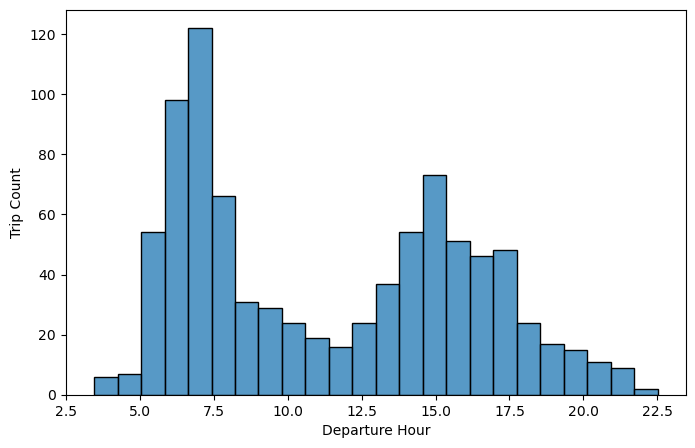

In [15]:
taxi_data = combined_data[combined_data.transport == 8]
taxi_data["departure_hour"] = taxi_data["departure_time"] / 3600
print(len(taxi_data))

plt.figure(figsize=(8,5))
sns.histplot(taxi_data["departure_hour"], bins=24)
plt.xlabel("Departure Hour")
plt.ylabel("Trip Count")
plt.show()

# Test result 3 (waiting time = 10min)

In [3]:
session_dir = "/home/majue/sip_case_study/Pseudo-PFLOW/nishioshi_case/"
labor_path = os.path.join(session_dir, f'person/trip_taxi/',f"23/3/",f"trip_23213_labor.csv")
nolabor_path = os.path.join(session_dir, f'person/trip_taxi',f"23/3/",f"trip_23213_nolabor.csv")
student_path = os.path.join(session_dir, f'person/trip_taxi',f"23/3/",f"trip_23213_student.csv")

base_columns = ['person_id','departure_time','origin_lon','origin_lat','destination_lon','destination_lat','transport','purpose','labor']
labor_data = safe_read_csv(labor_path, base_columns)
nolabor_data = safe_read_csv(nolabor_path, base_columns)
student_data = safe_read_csv(student_path, base_columns)

combined_data = pd.concat([labor_data, nolabor_data, student_data], ignore_index=True, axis=0)

print(len(labor_data))
print(len(nolabor_data))
print(len(student_data))
print(len(combined_data))

print(combined_data.transport.value_counts())
print(combined_data.transport.value_counts(normalize=True) * 100)

3599
2345
1569
7513
transport
3    4662
0     960
2     913
8     570
1     309
5      79
4      20
Name: count, dtype: int64
transport
3    62.052442
0    12.777852
2    12.152269
8     7.586849
1     4.112871
5     1.051511
4     0.266205
Name: proportion, dtype: float64


In [4]:
combined_data.head()

,person_id,departure_time,origin_lon,origin_lat,destination_lon,destination_lat,transport,purpose,labor
0,74822164,55987,137.009235,34.999011,137.048281,34.860419,3,1,21
1,74822266,22646,137.060718,34.878912,137.136701,34.848263,3,2,21
2,74822266,45153,137.136701,34.848263,137.060718,34.878912,3,1,21
3,74822388,24006,137.077588,34.874041,137.095635,34.891157,3,2,21
4,74822388,26545,137.095635,34.891157,137.062110,34.860515,3,3,21


In [9]:
def haversine(lon1, lat1, lon2, lat2):
    R = 6371000  # Earth radius in meters
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c  # meters

combined_data["od_distance_m"] = haversine(
    combined_data.origin_lon,
    combined_data.origin_lat,
    combined_data.destination_lon,
    combined_data.destination_lat
)
combined_data["od_distance_km"] = combined_data["od_distance_m"] / 1000

combined_data.groupby("transport")["od_distance_km"].describe()

,count,mean,std,min,25%,50%,75%,max
transport,,,,,,,,
0,960.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,309.0,0.386552,0.221440,0.005834,0.195123,0.349854,0.533853,1.038949
2,913.0,1.120841,1.059858,0.005834,0.480244,0.800970,1.350199,6.009784
3,4662.0,7.152826,8.419501,0.111523,1.787829,4.267635,8.863732,45.157595
4,20.0,3.636951,1.880862,1.461495,2.148479,3.990717,4.593608,8.559297
5,79.0,2.145796,1.683792,0.018850,0.905574,1.562801,2.604678,6.487518
8,570.0,13.478072,14.893175,0.517607,4.060208,8.144259,16.018291,91.343533


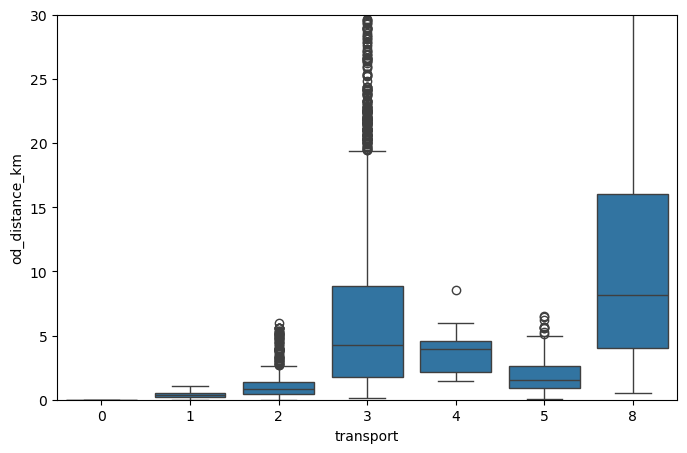

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=combined_data, x="transport", y="od_distance_km")
plt.ylim(0, 30)  # 避免极端值拉长
plt.show()

570


/tmp/ipykernel_1319906/2248104164.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  taxi_data["departure_hour"] = taxi_data["departure_time"] / 3600


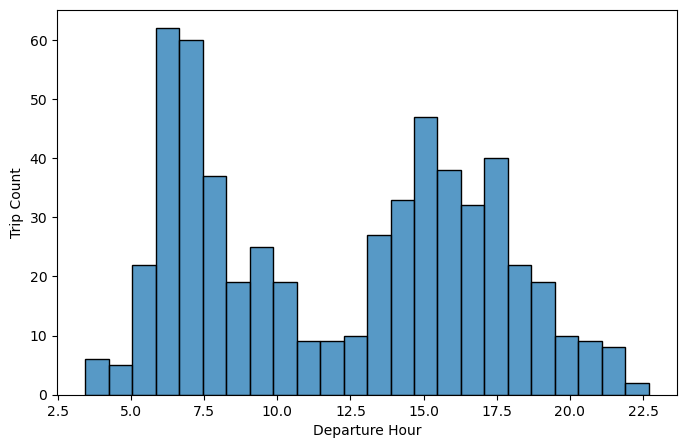

In [11]:
taxi_data = combined_data[combined_data.transport == 8]
taxi_data["departure_hour"] = taxi_data["departure_time"] / 3600
print(len(taxi_data))

plt.figure(figsize=(8,5))
sns.histplot(taxi_data["departure_hour"], bins=24)
plt.xlabel("Departure Hour")
plt.ylabel("Trip Count")
plt.show()